In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def plot_architecture_method_comparisons(
    csv_path,
    architecture_name=None,
    accuracy_col="val_acc",
    loss_col="val_loss",
    epoch_col="epoch",
    method_col="method",
    time_col="epoch_time_sec",
    params_col="trainable_params",
    memory_col="peak_memory_mb",
    summary_mode="best",
    save_dir="plots",   # ✅ default folder
    show=True,
):
    csv_path = Path(csv_path)
    df = pd.read_csv(csv_path)

    if architecture_name is None:
        architecture_name = csv_path.stem

    # Ensure output directory exists
    save_dir = Path(save_dir) / architecture_name
    save_dir.mkdir(parents=True, exist_ok=True)

    # Sort and compute cumulative time
    df = df.sort_values([method_col, epoch_col])
    df["cumulative_time_sec"] = df.groupby(method_col)[time_col].cumsum()

    # Create summary per method
    summary_rows = []
    for method, g in df.groupby(method_col):
        g = g.sort_values(epoch_col)

        if summary_mode == "best":
            row = g.loc[g[accuracy_col].idxmax()]
        elif summary_mode == "final":
            row = g.iloc[-1]
        else:
            raise ValueError("summary_mode must be 'best' or 'final'")

        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)

    # -------------------------------
    # 1. Accuracy vs Cumulative Time
    # -------------------------------
    fig1, ax1 = plt.subplots()
    for method, g in df.groupby(method_col):
        ax1.plot(
            g["cumulative_time_sec"],
            g[accuracy_col],
            marker="o",
            label=method
        )

    ax1.set_title(f"{architecture_name}: Accuracy vs Cumulative Time")
    ax1.set_xlabel("Cumulative Time (sec)")
    ax1.set_ylabel(accuracy_col)
    ax1.legend()
    ax1.grid(True)

    fig1.savefig(save_dir / "accuracy_vs_cumulative_time.png", dpi=300)

    # -------------------------------
    # 2. Accuracy vs Trainable Params
    # -------------------------------
    fig2, ax2 = plt.subplots()
    ax2.scatter(summary_df[params_col], summary_df[accuracy_col])

    for _, row in summary_df.iterrows():
        ax2.annotate(row[method_col],
                     (row[params_col], row[accuracy_col]))

    ax2.set_title(f"{architecture_name}: Accuracy vs Trainable Params")
    ax2.set_xlabel("Trainable Parameters")
    ax2.set_ylabel(accuracy_col)
    ax2.grid(True)

    fig2.savefig(save_dir / "accuracy_vs_trainable_params.png", dpi=300)

    # -------------------------------
    # 3. Loss vs Peak Memory
    # -------------------------------
    fig3, ax3 = plt.subplots()
    ax3.scatter(summary_df[memory_col], summary_df[loss_col])

    for _, row in summary_df.iterrows():
        ax3.annotate(row[method_col],
                     (row[memory_col], row[loss_col]))

    ax3.set_title(f"{architecture_name}: Loss vs Peak Memory")
    ax3.set_xlabel("Peak Memory (MB)")
    ax3.set_ylabel(loss_col)
    ax3.grid(True)

    fig3.savefig(save_dir / "loss_vs_peak_memory.png", dpi=300)

    if show:
        plt.show()
    else:
        plt.close('all')

    print(f"✅ Plots saved in: {save_dir}")

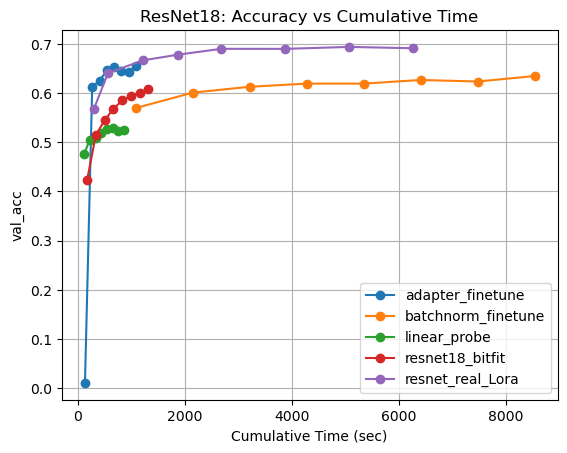

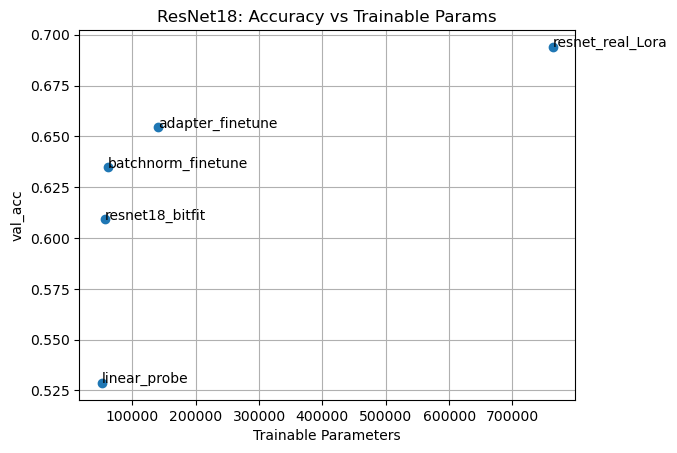

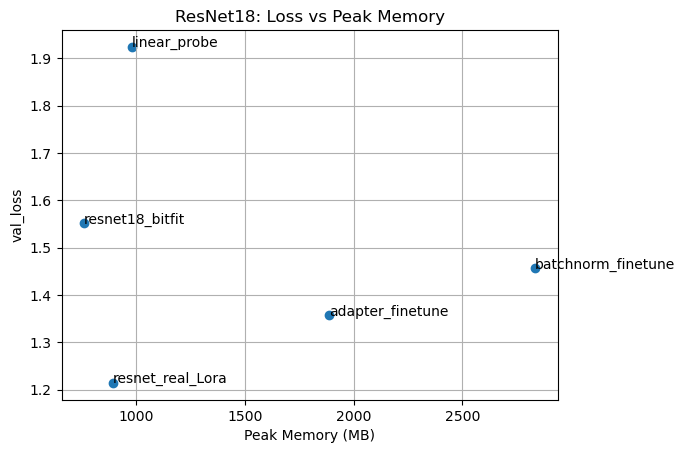

✅ Plots saved in: plots\ResNet18


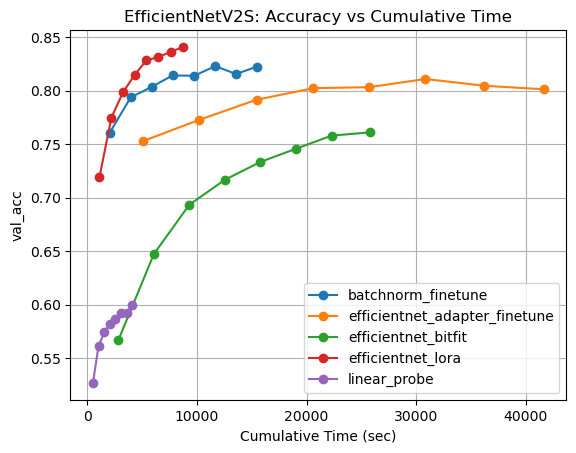

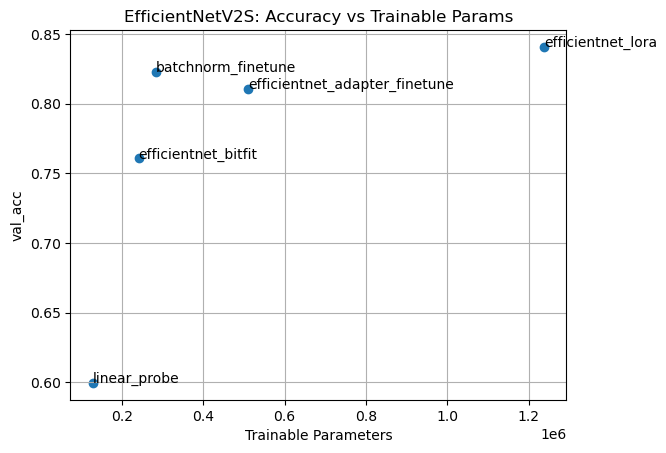

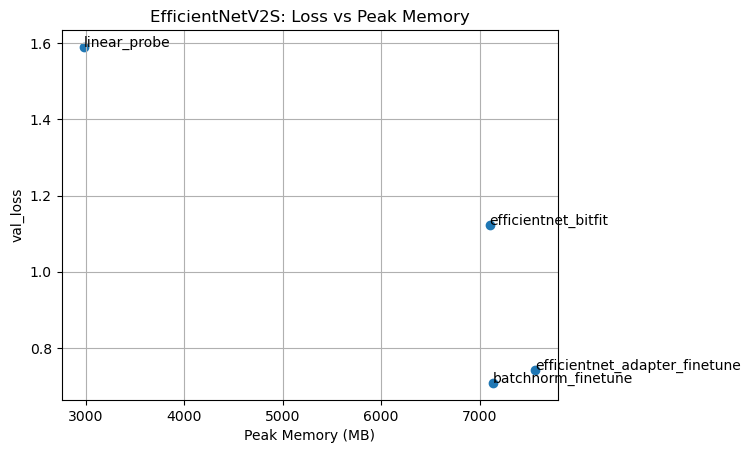

✅ Plots saved in: plots\EfficientNetV2S


In [7]:
# ResNet18 plots
plot_architecture_method_comparisons(
    "D:/Project_Final/training_scripts/ResNet18/results/ResNet18_metrics.csv",
    architecture_name="ResNet18",
    accuracy_col="val_acc",
    loss_col="val_loss",
    summary_mode="best",
    save_dir="plots"
)

# EfficientNetV2S plots
plot_architecture_method_comparisons(
    "D:/Project_Final/training_scripts/EfficientNetV2/results/EfficientNetV2s_metrics.csv",
    architecture_name="EfficientNetV2S",
    accuracy_col="val_acc",
    loss_col="val_loss",
    summary_mode="best",
    save_dir="plots"
)